# **06 - Hierarchical clustering of districts and Gaussian mixture**

Two more unsupervised approaches, compared with K-Means (`05_kmeans_clustering.ipynb`) under the same leakage rules: every statistic is learned on TRAIN (2022-2024) only, the number of tiers / components is chosen without TEST, and TEST rows receive labels or probabilities only through `transform` / `predict`.

**Part A - Ward clustering of the 25 districts.** One profile vector per district from TRAIN: median `log1p(target)` of the track, median `log_area`, median `building_age` and the four building-type shares. The profiles are standardized and clustered with Ward linkage; the dendrogram is cut into 3 to 6 tiers (`district_tier`, T0 = lowest median target). Rule fixed before looking at the results: highest silhouette among the cuts in which every tier has at least 2 districts. The median log target of a district is a target-derived statistic, but it is computed on TRAIN only and at district level (25 groups), and it is re-learned inside every fit. Models: `ridge_time_tier` and `hgb_time_tier`.

**Part B - Gaussian mixture on contract structure.** Features: `log_area`, `floor` (median-imputed), `building_age` and the building-type dummies, all standardized on TRAIN. The number of components (2..12) and the covariance type (full, tied, diag, spherical) are chosen by the minimum BIC on TRAIN, with AIC reported (`reg_covar=0.001` because the dummies make some directions almost constant; two initializations per fit). Models: `gmm_median` (hard assignment, TRAIN median of the component), `ridge_time_gmm` and `hgb_time_gmm` (soft assignment probabilities as numeric features).

**Reference models.** `ridge_time` and `hgb_time` hyperparameters are loaded from `reports/metrics` and reused without retuning, so each difference to the plain model isolates the effect of the unsupervised feature. A feature counts as an improvement only if the 95% paired-bootstrap interval of the WAPE difference is entirely below zero **and** the difference is at least 0.10 WAPE points (materiality threshold). The threshold was added after the first execution, in which `ridge_time_tier` was flagged with a difference of exactly 0.0000: the tier is a function of the district, which `ridge_time` already has as a one-hot feature, so the interval "below zero" there is a floating-point artifact.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import adjusted_rand_score

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.io import save_run
from rent_model.metrics import all_metrics, paired_bootstrap_wape_diff
from rent_model.splits import temporal_split
from rent_model.unsupervised import (BoostedWithLabeler, DistrictTierer, GMMLabeler, GMMMedian, TIER_COLUMN,
                                     build_ridge_pipeline, district_profiles, name_tiers, prob_columns,
                                     select_gmm, select_n_tiers, tier_table)

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data and reference models

In [2]:
df = load_clean()
data = {}
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(train=train, test=test, target=spec['target'],
                       X_train=build_features(train, track, include_time=True), y_train_log=build_target(train, track),
                       X_test=build_features(test, track, include_time=True), y_test=test[spec['target']])
    print(f"{track}: train {len(train):,} rows, test {len(test):,} rows")

def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

params = {track: {'ridge_alpha': last_run(track, 'ridge_time')['meta']['params']['alpha'],
                  'hgb': last_run(track, 'hgb_time')['meta']['params']} for track in config.TRACKS}
for track in config.TRACKS:
    print(track, '-> ridge_time alpha:', params[track]['ridge_alpha'], '| hgb_time params:', params[track]['hgb'])

jeonse: train 138,848 rows, test 37,935 rows
wolse: train 152,714 rows, test 57,829 rows
jeonse -> ridge_time alpha: 0.01 | hgb_time params: {'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0.0}
wolse -> ridge_time alpha: 0.01 | hgb_time params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 10.0}


## Part A - Hierarchical clustering of districts

### District profiles (TRAIN)

In [3]:
profiles = {t: district_profiles(data[t]['X_train'], data[t]['y_train_log']) for t in config.TRACKS}
for track in config.TRACKS:
    print(f'{track}: {len(profiles[track])} districts')
    display(profiles[track].rename(columns=lambda c: c.replace('share_', 'sh_').replace('Row house / Villa (multi-unit)', 'RowHouse')
                                   .replace('Detached / Multi-household house', 'Detached')).round(3))

jeonse: 25 districts


,median_log_target,median_log_area,median_building_age,sh_Apartment,sh_Officetel,sh_RowHouse,sh_Detached
district_name,,,,,,,
Dobong-gu,9.9520,3.9830,28.0000,0.5950,0.0660,0.2200,0.1180
Dongdaemun-gu,10.2400,4.0230,12.0000,0.4930,0.1520,0.1550,0.1990
Dongjak-gu,10.3740,4.0890,16.0000,0.4790,0.0170,0.2320,0.2720
Eunpyeong-gu,10.0430,4.0450,12.0000,0.4200,0.0610,0.4000,0.1180
Gangbuk-gu,9.7980,3.9230,20.0000,0.3650,0.0200,0.3420,0.2730
Gangdong-gu,10.3510,4.0870,10.0000,0.5610,0.0650,0.2590,0.1150
Gangnam-gu,10.8400,4.0940,20.0000,0.6470,0.0920,0.1860,0.0750
Gangseo-gu,10.0430,3.7890,10.0000,0.4480,0.2150,0.2850,0.0510
Geumcheon-gu,9.9240,3.5400,7.0000,0.2810,0.2960,0.2670,0.1560


wolse: 25 districts


,median_log_target,median_log_area,median_building_age,sh_Apartment,sh_Officetel,sh_RowHouse,sh_Detached
district_name,,,,,,,
Dobong-gu,3.9320,3.7040,28.0000,0.3910,0.1300,0.1740,0.3050
Dongdaemun-gu,3.9890,3.3470,12.0000,0.2750,0.2130,0.1120,0.4000
Dongjak-gu,3.9320,3.3430,13.0000,0.2300,0.0290,0.1860,0.5550
Eunpyeong-gu,3.8500,3.6350,12.0000,0.3070,0.1510,0.2690,0.2720
Gangbuk-gu,3.8290,3.5080,19.0000,0.2350,0.0670,0.2120,0.4860
Gangdong-gu,3.8710,3.6300,11.0000,0.3860,0.1160,0.2370,0.2620
Gangnam-gu,4.4310,3.7840,19.0000,0.4790,0.1090,0.2020,0.2090
Gangseo-gu,3.9320,3.3860,10.0000,0.2750,0.3780,0.2030,0.1450
Geumcheon-gu,3.8290,3.3790,8.0000,0.2090,0.2660,0.1710,0.3540


### Choice of the number of tiers (TRAIN only)

In [4]:
n_tiers, tier_selection = {}, {}
for track in config.TRACKS:
    n_tiers[track], tier_selection[track] = select_n_tiers(profiles[track])
    print(f'{track}: chosen number of tiers = {n_tiers[track]}')
    display(tier_selection[track])

jeonse: chosen number of tiers = 3


,silhouette,min_tier_size,tier_sizes,eligible
n_tiers,,,,
3,0.2825,5,"[12, 8, 5]",True
4,0.2615,3,"[9, 8, 5, 3]",True
5,0.2434,3,"[9, 5, 4, 4, 3]",True
6,0.2546,2,"[9, 4, 4, 3, 3, 2]",True


wolse: chosen number of tiers = 4


,silhouette,min_tier_size,tier_sizes,eligible
n_tiers,,,,
3,0.2232,7,"[10, 8, 7]",True
4,0.2335,3,"[10, 7, 5, 3]",True
5,0.2216,3,"[7, 7, 5, 3, 3]",True
6,0.2226,3,"[7, 5, 4, 3, 3, 3]",True


### Dendrogram and tier map

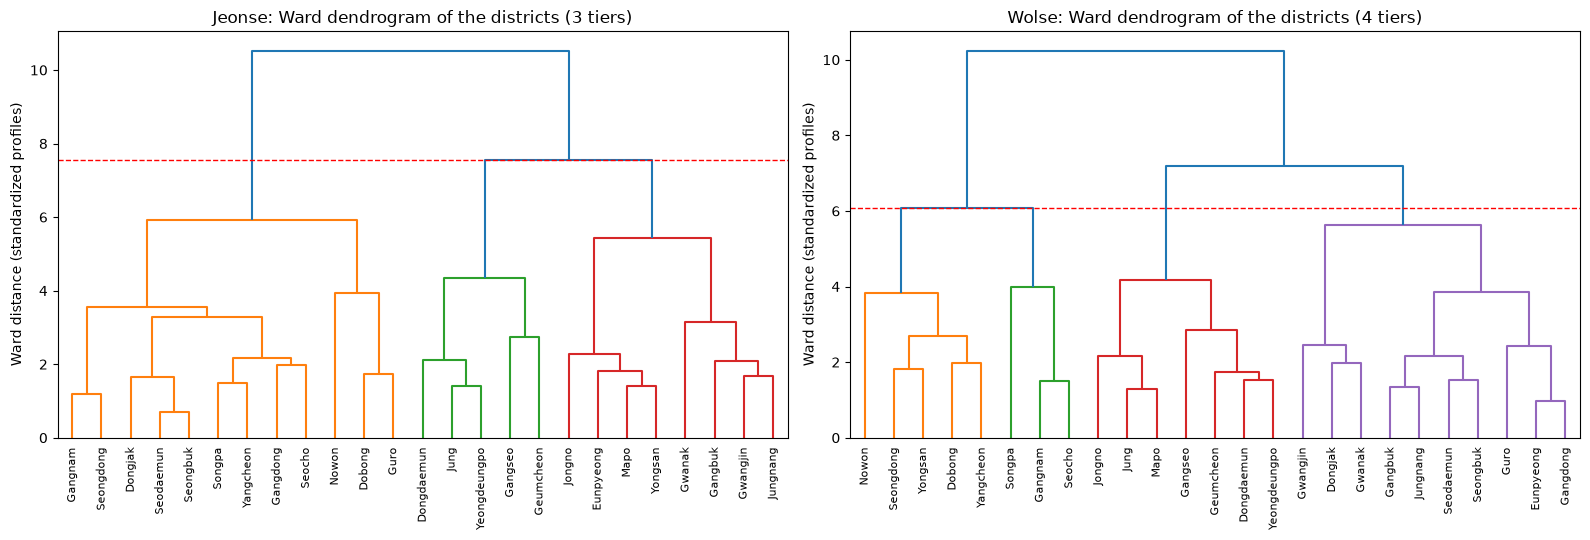

jeonse: tier map (median_target in 10,000 KRW, medians over the districts of each tier)


,n_districts,median_log_area,median_building_age,sh_Apartment,sh_Officetel,sh_RowHouse,sh_Detached,median_target
tier,,,,,,,,
"T0 lower-price, apartment-light",8,3.9230,16.5000,0.3680,0.0650,0.3300,0.2110,"23,979.1580"
T1 mid-price,5,3.8760,12.0000,0.4590,0.2150,0.2050,0.1280,"28,000.0000"
"T2 higher-price, apartment-heavy",12,4.0910,19.0000,0.5800,0.0620,0.2310,0.1150,"32,636.8260"


  T0: Eunpyeong, Gangbuk, Gwanak, Gwangjin, Jongno, Jungnang, Mapo, Yongsan
  T1: Dongdaemun, Gangseo, Geumcheon, Jung, Yeongdeungpo
  T2: Dobong, Dongjak, Gangdong, Gangnam, Guro, Nowon, Seocho, Seodaemun, Seongbuk, Seongdong, Songpa, Yangcheon
wolse: tier map (median_target in 10,000 KRW, medians over the districts of each tier)


,n_districts,median_log_area,median_building_age,sh_Apartment,sh_Officetel,sh_RowHouse,sh_Detached,median_target
tier,,,,,,,,
T0 lowest-price,10,3.5350,15.0000,0.2930,0.0990,0.1980,0.4450,46.4970
"T1 lower-mid-price, apartment-light",7,3.3980,12.0000,0.2750,0.2250,0.1770,0.2790,53.0000
"T2 upper-mid-price, apartment-heavy",5,3.7840,22.0000,0.4400,0.0810,0.1740,0.3050,53.0000
T3 highest-price,3,3.7840,15.0000,0.4320,0.1090,0.2580,0.2080,75.0000


  T0: Dongjak, Eunpyeong, Gangbuk, Gangdong, Guro, Gwanak, Gwangjin, Jungnang, Seodaemun, Seongbuk
  T1: Dongdaemun, Gangseo, Geumcheon, Jongno, Jung, Mapo, Yeongdeungpo
  T2: Dobong, Nowon, Seongdong, Yangcheon, Yongsan
  T3: Gangnam, Seocho, Songpa
Adjusted Rand index between the Jeonse and the Wolse district tiers: 0.1967


In [5]:
tierers, names = {}, {}
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, track in zip(axes, config.TRACKS):
    d = data[track]
    tierers[track] = DistrictTierer(n_tiers=n_tiers[track]).fit(d['X_train'], d['y_train_log'])
    tree = tierers[track].linkage_
    cut = tree[-(n_tiers[track] - 1), 2] - 1e-9   # height just below the merge that would reduce the number of tiers
    dendrogram(tree, labels=[s.replace('-gu', '') for s in tierers[track].profiles_.index], color_threshold=cut,
               leaf_rotation=90, leaf_font_size=8, ax=ax)
    ax.axhline(cut, color='red', ls='--', lw=1)
    ax.set_title(f'{track.capitalize()}: Ward dendrogram of the districts ({n_tiers[track]} tiers)')
    ax.set_ylabel('Ward distance (standardized profiles)')
plt.tight_layout(); plt.show()

for track in config.TRACKS:
    table = tier_table(tierers[track])
    names[track] = name_tiers(table)
    print(f'{track}: tier map (median_target in 10,000 KRW, medians over the districts of each tier)')
    show = table.rename(index=names[track]).rename(columns=lambda c: c.replace('share_', 'sh_').replace('Row house / Villa (multi-unit)', 'RowHouse')
                                                  .replace('Detached / Multi-household house', 'Detached'))
    display(show.drop(columns=['districts', 'median_log_target']).round(3))
    for tier, row in table.iterrows():
        print(f'  {tier}: {row["districts"]}')

same = adjusted_rand_score(*[pd.Series(tierers['jeonse'].mapping_).reindex(sorted(tierers['jeonse'].mapping_)),
                             pd.Series(tierers['wolse'].mapping_).reindex(sorted(tierers['jeonse'].mapping_))])
print(f'Adjusted Rand index between the Jeonse and the Wolse district tiers: {same:.4f}')

**Interpretation.** The rule selects 3 tiers in Jeonse (silhouette 0.2825, against 0.2615, 0.2434 and 0.2546 for 4, 5 and 6 tiers) and 4 tiers in Wolse (0.2335, against 0.2232, 0.2216 and 0.2226 for 3, 5 and 6 tiers). All silhouettes are low, so the 25 districts do not form well-separated groups; the tiers are a convenient partition of a continuum. Tier numbers follow the median log target of their districts, but the tiers are not a pure price ranking because five other profile variables enter the distance: in Jeonse the higher-price, apartment-heavy tier `T2` (12 districts, median target 32,636.8260) includes Gangnam-gu (median log target 10.8400) but also Dobong-gu (9.9520) and Nowon-gu (10.0970), whose apartment shares are 0.5950 and 0.8720. In Wolse the highest-price tier `T3` contains only Gangnam, Seocho and Songpa (median target 75.0000), while `T1` and `T2` have the same median target (53.0000) and differ in structure (`T2` has a median building age of 22.0000 years against 12.0000 for `T1`). The Jeonse and Wolse tiers are different partitions (adjusted Rand index 0.1967).

## Part B - Gaussian mixture on contract structure

### Choice of components and covariance type (BIC / AIC on TRAIN)

jeonse: minimum BIC at covariance_type='full', k=12 (BIC -1,726,400.6); minimum AIC at covariance_type='full', k=12; all fits converged: True


,min,k_at_min
covariance_type,,
diag,"-1,717,102.5798",12
full,"-1,726,400.6010",12
spherical,"1,259,844.1079",12
tied,"-1,550,034.9465",11


wolse: minimum BIC at covariance_type='full', k=11 (BIC -2,014,190.4); minimum AIC at covariance_type='full', k=11; all fits converged: True


,min,k_at_min
covariance_type,,
diag,"-2,011,472.5267",12
full,"-2,014,190.4145",11
spherical,"1,411,236.4866",12
tied,"-1,652,730.2101",11


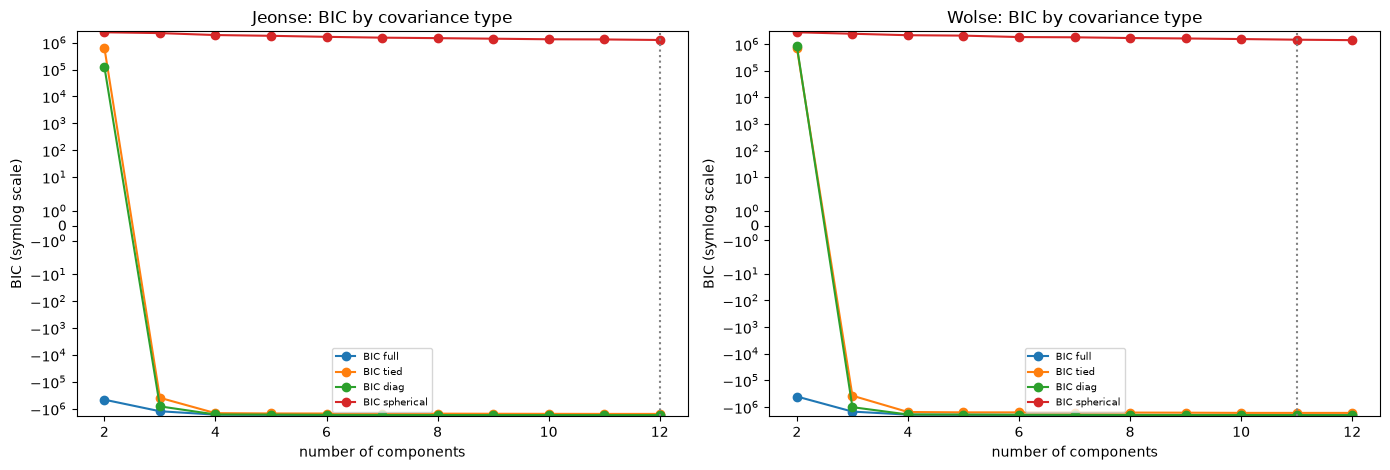

In [6]:
gmm_choice, gmm_table = {}, {}
for track in config.TRACKS:
    cov, k, table = select_gmm(data[track]['X_train'])
    gmm_choice[track], gmm_table[track] = (cov, k), table
    aic_cov, aic_k = table['aic'].idxmin()
    print(f"{track}: minimum BIC at covariance_type='{cov}', k={k} (BIC {table.loc[(cov, k), 'bic']:,.1f}); "
          f"minimum AIC at covariance_type='{aic_cov}', k={aic_k}; all fits converged: {bool(table['converged'].all())}")
    best_by_cov = table.groupby(level='covariance_type')['bic'].agg(['min', 'idxmin']).assign(
        k_at_min=lambda t: t['idxmin'].map(lambda i: i[1])).drop(columns='idxmin')
    display(best_by_cov)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, track in zip(axes, config.TRACKS):
    table = gmm_table[track]
    for cov in table.index.get_level_values('covariance_type').unique():
        sub = table.loc[cov]
        ax.plot(sub.index, sub['bic'], marker='o', label=f'BIC {cov}')
    ax.axvline(gmm_choice[track][1], color='gray', ls=':')
    ax.set_yscale('symlog'); ax.set_xlabel('number of components'); ax.set_ylabel('BIC (symlog scale)')
    ax.set_title(f'{track.capitalize()}: BIC by covariance type'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

**Interpretation.** The minimum BIC is reached with a full covariance matrix in both tracks: 12 components in Jeonse (BIC -1,726,400.6) and 11 in Wolse (-2,014,190.4), and the minimum AIC selects the same combination. In Jeonse the minimum is at the upper edge of the grid (k = 12), and in Wolse the diagonal covariance also has its minimum at k = 12, so more components could still lower the BIC; the grid was not extended. Spherical covariances have positive BIC (1,259,844.1 and 1,411,236.5) and are clearly worse. BIC values are negative because they are computed from densities of standardized variables, and the building-type dummies are almost constant inside a component, which makes densities large; the values are only comparable within this table. All fits converged.

### Component profiles (TRAIN hard assignment)

In [7]:
labelers = {}
for track in config.TRACKS:
    d = data[track]; cov, k = gmm_choice[track]
    labelers[track] = GMMLabeler(n_components=k, covariance_type=cov).fit(d['X_train'])
    comp_train = labelers[track].components(d['X_train']); comp_test = labelers[track].components(d['X_test'])
    frame = d['X_train'][['log_area', 'floor', 'building_age']].assign(area_sqm=np.exp(d['X_train']['log_area']), comp=comp_train)
    profile = frame.groupby('comp').agg(n=('area_sqm', 'size'), median_area_sqm=('area_sqm', 'median'),
                                        median_floor=('floor', 'median'), median_building_age=('building_age', 'median'))
    profile['share_pct'] = profile['n'] / profile['n'].sum() * 100
    profile['mean_weight'] = labelers[track].gmm_.weights_
    types = pd.crosstab(comp_train, d['X_train']['building_type'].to_numpy(), normalize='index') * 100
    profile = profile.join(types.rename(columns={'Row house / Villa (multi-unit)': 'pct_RowHouse', 'Detached / Multi-household house': 'pct_Detached',
                                                 'Apartment': 'pct_Apartment', 'Officetel': 'pct_Officetel'}))
    profile['median_target'] = d['train'][d['target']].groupby(comp_train).median()
    profile['n_test'] = pd.Series(comp_test).value_counts().reindex(profile.index).fillna(0).astype(int)
    profile['mean_max_prob_test'] = pd.Series(labelers[track].probabilities(d['X_test']).max(axis=1)).groupby(comp_test).mean()
    print(f'{track}: {k} components, covariance_type={cov} (median_target in 10,000 KRW, description only)')
    display(profile.drop(columns=['n']).round(3))
    print(f'{track}: mean of the largest posterior probability on TEST = {labelers[track].probabilities(d["X_test"]).max(axis=1).mean():.4f}')

jeonse: 12 components, covariance_type=full (median_target in 10,000 KRW, description only)


,median_area_sqm,median_floor,median_building_age,share_pct,mean_weight,pct_Apartment,pct_Detached,pct_Officetel,pct_RowHouse,median_target,n_test,mean_max_prob_test
comp,,,,,,,,,,,,
0,20.3000,9.0000,5.0000,1.5410,0.0160,100.0000,0.0000,0.0000,0.0000,"20,000.0000",435,0.9430
1,26.4300,5.0000,6.0000,4.7530,0.0590,0.0000,0.0000,0.0000,100.0000,"21,200.0000",1417,0.7810
2,59.9700,3.0000,31.0000,8.9290,0.0870,100.0000,0.0000,0.0000,0.0000,"38,000.0000",3943,0.7720
3,40.2000,NaN,30.0000,11.1210,0.1120,0.0000,100.0000,0.0000,0.0000,"13,000.0000",3554,0.9910
4,25.3700,7.0000,5.0000,9.7340,0.0970,0.0000,0.0000,100.0000,0.0000,"20,900.0000",3369,1.0000
5,84.6800,5.0000,14.0000,12.3230,0.1090,100.0000,0.0000,0.0000,0.0000,"53,000.0000",5193,0.7120
6,19.2700,NaN,5.0000,2.5030,0.0250,0.0000,100.0000,0.0000,0.0000,"11,020.0000",423,0.9090
7,29.9000,3.0000,5.0000,9.5950,0.0810,0.0000,0.0000,0.0000,100.0000,"24,500.0000",2719,0.7270
8,84.7800,12.0000,7.0000,9.3820,0.1000,100.0000,0.0000,0.0000,0.0000,"62,000.0000",4136,0.7800


jeonse: mean of the largest posterior probability on TEST = 0.8328


wolse: 11 components, covariance_type=full (median_target in 10,000 KRW, description only)


,median_area_sqm,median_floor,median_building_age,share_pct,mean_weight,pct_Apartment,pct_Detached,pct_Officetel,pct_RowHouse,median_target,n_test,mean_max_prob_test
comp,,,,,,,,,,,,
0,36.2300,NaN,22.0000,7.7960,0.1040,0.0000,100.0000,0.0000,0.0000,50.0000,4969,0.8550
1,33.7400,9.0000,3.0000,8.9260,0.0830,100.0000,0.0000,0.0000,0.0000,43.0000,5351,0.8570
2,45.1650,3.0000,21.0000,10.7430,0.1190,0.0000,0.0000,0.0000,100.0000,50.0000,6773,0.9400
3,20.8400,8.0000,6.0000,9.6340,0.0880,0.0000,0.0000,100.0000,0.0000,63.0000,6328,0.8740
4,83.6400,5.0000,14.0000,7.8020,0.0760,100.0000,0.0000,0.0000,0.0000,100.0000,3938,0.7320
5,18.1800,NaN,6.0000,7.2260,0.0690,0.0000,100.0000,0.0000,0.0000,45.0000,3850,0.8970
6,84.8700,18.0000,14.0000,5.5510,0.0640,100.0000,0.0000,0.0000,0.0000,135.0000,2976,0.8130
7,58.9000,8.0000,31.0000,10.6820,0.1060,100.0000,0.0000,0.0000,0.0000,70.0000,5646,0.8950
8,25.4600,4.0000,6.0000,9.7180,0.0860,0.0000,0.0000,0.0000,100.0000,50.0000,5134,0.8190


wolse: mean of the largest posterior probability on TEST = 0.8567


**Interpretation.** Every component is pure in building type (one type has 100.0000% of its TRAIN rows in all 12 Jeonse and all 11 Wolse components), so the mixture splits each building type into sub-segments by area, floor and age. For example, Jeonse apartments are split into six components with median areas between 20.3000 and 84.8800 m2, median floors between 3.0000 and 22.0000 and median TRAIN targets between 20,000 and 63,000; in Wolse the apartment components range from a median target of 43.0000 (33.7400 m2, floor 9.0000, age 3.0000) to 135.0000 (84.8700 m2, floor 18.0000). Component assignments are soft: the mean of the largest posterior probability on TEST is 0.8328 in Jeonse and 0.8567 in Wolse, and the means by component range from 0.7120 to 1.0000 in Jeonse and from 0.7320 to 0.9400 in Wolse.

## Models

In [8]:
fitted, preds, rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]; alpha = params[track]['ridge_alpha']; hgb = params[track]['hgb']
    k = gmm_choice[track][1]; cov = gmm_choice[track][0]
    models = {
        'gmm_median': GMMMedian(n_components=k, covariance_type=cov),
        'ridge_time_tier': build_ridge_pipeline(DistrictTierer(n_tiers[track]), alpha, extra_categorical=[TIER_COLUMN]),
        'hgb_time_tier': BoostedWithLabeler(DistrictTierer(n_tiers[track]), extra_categorical=[TIER_COLUMN], **hgb),
        'ridge_time_gmm': build_ridge_pipeline(GMMLabeler(k, cov), alpha, extra_numeric=prob_columns(k)),
        'hgb_time_gmm': BoostedWithLabeler(GMMLabeler(k, cov), extra_numeric=prob_columns(k), **hgb),
    }
    for model_id, model in models.items():
        if model_id == 'gmm_median':
            model.fit(d['X_train'], d['train'][d['target']].to_numpy())
            pred = model.predict(d['X_test'])
        else:
            model.fit(d['X_train'], d['y_train_log'])
            pred = np.expm1(np.maximum(model.predict(d['X_test']), 0.0))
        fitted[(track, model_id)], preds[(track, model_id)] = model, pred
        rows.append({'track': track, 'model_id': model_id, **all_metrics(d['y_test'].to_numpy(), pred)})
metrics = pd.DataFrame(rows)
print('Fitted', len(fitted), 'models')

Fitted 10 models


## TEST comparison

In [9]:
REFERENCES = ['baseline_district_type', 'ridge_time', 'hgb_time', 'kmeans_median', 'ridge_time_kmeans', 'hgb_time_kmeans']
cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[cols]
    for ref_id in REFERENCES:
        run = last_run(track, ref_id)
        table.loc[f'(ref) {ref_id}'] = [run[c] for c in cols]
    print(f'TEST metrics - {track}')
    display(table)

TEST metrics - jeonse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
gmm_median,"37,935.0000",37.0993,"16,720.9343",28.5714,-7.4627,-18.5626,0.5173,0.5311
ridge_time_tier,"37,935.0000",24.0436,"10,836.6377",18.2974,-8.3812,-11.9167,0.3520,0.7829
hgb_time_tier,"37,935.0000",17.3508,"7,820.1270",13.0637,-3.9028,-3.9739,0.2820,0.8607
ridge_time_gmm,"37,935.0000",23.3908,"10,542.4070",17.2889,-7.3993,-11.3437,0.3422,0.7948
hgb_time_gmm,"37,935.0000",17.3771,"7,832.0040",13.0598,-3.9049,-4.0547,0.2827,0.8600
(ref) baseline_district_type,"37,935.0000",34.4687,"15,535.3072",26.3158,-6.3830,-14.4528,0.4860,0.5860
(ref) ridge_time,"37,935.0000",24.0436,"10,836.6378",18.2974,-8.3812,-11.9167,0.3520,0.7829
(ref) hgb_time,"37,935.0000",17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,0.2817,0.8609
(ref) kmeans_median,"37,935.0000",41.7619,"18,822.4358",32.9268,-8.3333,-20.4745,0.5750,0.4207


TEST metrics - wolse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
gmm_median,"57,829.0000",51.8733,38.8865,35.8974,-6.6667,-19.8396,0.8164,0.0952
ridge_time_tier,"57,829.0000",51.3471,38.4920,40.8782,-22.7534,-30.8606,0.7497,0.2372
hgb_time_tier,"57,829.0000",45.7446,34.2921,37.3482,-18.4341,-22.5572,0.6970,0.3405
ridge_time_gmm,"57,829.0000",50.4504,37.8198,40.3180,-22.0658,-29.9126,0.7422,0.2523
hgb_time_gmm,"57,829.0000",45.5640,34.1567,37.2668,-18.1697,-22.3026,0.6959,0.3426
(ref) baseline_district_type,"57,829.0000",51.9313,38.9300,35.5932,-6.2500,-19.5340,0.8137,0.1013
(ref) ridge_time,"57,829.0000",51.3471,38.4920,40.8782,-22.7534,-30.8606,0.7497,0.2372
(ref) hgb_time,"57,829.0000",45.7417,34.2900,37.3742,-18.2042,-22.4644,0.6973,0.3400
(ref) kmeans_median,"57,829.0000",54.4581,40.8242,37.6471,-7.1429,-23.4074,0.8356,0.0522


**Interpretation (Jeonse).** `gmm_median` has a WAPE of 37.0993%, better than `kmeans_median` (41.7619%) but worse than `baseline_district_type` (34.4687%). The district tier does not change the supervised models: `ridge_time_tier` has exactly the WAPE of `ridge_time` (24.0436%) and `hgb_time_tier` 17.3508% against 17.3111% for `hgb_time`. The mixture probabilities lower the ridge WAPE to 23.3908% (and the median bias from -8.3812% to -7.3993%) but leave `hgb_time_gmm` at 17.3771%, slightly above `hgb_time`.

**Interpretation (Wolse).** `gmm_median` reaches 51.8733%, in line with `baseline_district_type` (51.9313%) and better than `kmeans_median` (54.4581%). `ridge_time_tier` equals `ridge_time` (51.3471%); `ridge_time_gmm` lowers it to 50.4504%; `hgb_time_tier` is 45.7446% and `hgb_time_gmm` 45.5640%, against 45.7417% for `hgb_time`. The biases hardly move (for example the median bias of `hgb_time_gmm` is -18.1697% against -18.2042% for `hgb_time`).

## Is any unsupervised feature better than bootstrap noise?

In [10]:
comparisons = [('ridge_time_tier', 'ridge_time'), ('hgb_time_tier', 'hgb_time'),
               ('ridge_time_gmm', 'ridge_time'), ('hgb_time_gmm', 'hgb_time'),
               ('ridge_time_tier', 'ridge_time_kmeans'), ('hgb_time_tier', 'hgb_time_kmeans'),
               ('ridge_time_gmm', 'ridge_time_kmeans'), ('hgb_time_gmm', 'hgb_time_kmeans'),
               ('gmm_median', 'baseline_district_type'), ('gmm_median', 'kmeans_median')]
delta_rows = []
for track in config.TRACKS:
    y_true = data[track]['y_test'].to_numpy()
    for new_id, ref_id in comparisons:
        ref = pd.read_parquet(config.PREDICTIONS_DIR / f'{track}__{ref_id}.parquet')
        assert np.allclose(ref['y_true'].to_numpy(), y_true), 'reference predictions are not in the same TEST order'
        boot = paired_bootstrap_wape_diff(y_true, preds[(track, new_id)], ref['y_pred'].to_numpy())
        delta_rows.append({'track': track, 'model': new_id, 'reference': ref_id,
                           'wape_new': float(metrics[(metrics['track'] == track) & (metrics['model_id'] == new_id)]['wape_pct'].iloc[0]),
                           'wape_ref': float(last_run(track, ref_id)['wape_pct']),
                           'delta_pts': boot['diff'], 'boot_se': boot['se'], 'ci95_low': boot['ci_low'], 'ci95_high': boot['ci_high'],
                           'ci_below_zero': bool(boot['ci_high'] < 0),
                           'material_improvement': bool(boot['ci_high'] < 0 and boot['diff'] <= -0.10)})
deltas = pd.DataFrame(delta_rows).set_index(['track', 'model', 'reference'])
display(deltas)
print('Material improvements (95% interval entirely below zero and difference <= -0.10 points):')
print(deltas[deltas['material_improvement']][['wape_new', 'wape_ref', 'delta_pts', 'boot_se', 'ci95_low', 'ci95_high']].round(4).to_string()
      if deltas['material_improvement'].any() else 'none')

wape_new  wape_ref  delta_pts  boot_se  ci95_low  ci95_high  ci_below_zero  material_improvement
track  model           reference                                                                                                               
jeonse ridge_time_tier ridge_time               24.0436   24.0436    -0.0000   0.0000   -0.0000    -0.0000           True                 False
       hgb_time_tier   hgb_time                 17.3508   17.3111     0.0397   0.0172    0.0089     0.0748          False                 False
       ridge_time_gmm  ridge_time               23.3908   24.0436    -0.6528   0.0394   -0.7278    -0.5762           True                  True
       hgb_time_gmm    hgb_time                 17.3771   17.3111     0.0661   0.0268    0.0143     0.1195          False                 False
       ridge_time_tier ridge_time_kmeans        24.0436   23.9687     0.0749   0.0238    0.0280     0.1220          False                 False
       hgb_time_tier   hgb_time_kmeans          17.3508   17.3424     0.0084   0.0186   -0.0279     0.0430          False                 False
       ridge_time_gmm  ridge_time_kmeans        23.3908   23.9687    -0.5779   0.0311   -0.6358    -0.5184           True                  True
       hgb_time_gmm    hgb_time_kmeans          17.3771   17.3424     0.0347   0.0267   -0.0159     0.0885          False                 False
       gmm_median      baseline_district_type   37.0993   34.4687     2.6306   0.1196    2.4008     2.8639          False                 False
                       kmeans_median            37.0993   41.7619    -4.6627   0.0975   -4.8665    -4.4736           True                  True
wolse  ridge_time_tier ridge_time               51.3471   51.3471    -0.0000   0.0000   -0.0000    -0.0000           True                 False
       hgb_time_tier   hgb_time                 45.7446   45.7417     0.0029   0.0114   -0.0192     0.0253          False                 False
       ridge_time_gmm  ridge_time               50.4504   51.3471    -0.8967   0.0415   -0.9762    -0.8115           True                  True
       hgb_time_gmm    hgb_time                 45.5640   45.7417    -0.1777   0.0335   -0.2434    -0.1106           True                  True
       ridge_time_tier ridge_time_kmeans        51.3471   50.9666     0.3804   0.0213    0.3379     0.4223          False                 False
       hgb_time_tier   hgb_time_kmeans          45.7446   45.7855    -0.0410   0.0197   -0.0785    -0.0015           True                 False
       ridge_time_gmm  ridge_time_kmeans        50.4504   50.9666    -0.5162   0.0469   -0.6065    -0.4280           True                  True
       hgb_time_gmm    hgb_time_kmeans          45.5640   45.7855    -0.2216   0.0273   -0.2755    -0.1696           True                  True
       gmm_median      baseline_district_type   51.8733   51.9313    -0.0580   0.1139   -0.2824     0.1746          False                 False
                       kmeans_median            51.8733   54.4581    -2.5848   0.0941   -2.7594    -2.3958           True                  True

Material improvements (95% interval entirely below zero and difference <= -0.10 points):
                                         wape_new  wape_ref  delta_pts  boot_se  ci95_low  ci95_high
track  model          reference                                                                     
jeonse ridge_time_gmm ridge_time          23.3908   24.0436    -0.6528   0.0394   -0.7278    -0.5762
                      ridge_time_kmeans   23.3908   23.9687    -0.5779   0.0311   -0.6358    -0.5184
       gmm_median     kmeans_median       37.0993   41.7619    -4.6627   0.0975   -4.8665    -4.4736
wolse  ridge_time_gmm ridge_time          50.4504   51.3471    -0.8967   0.0415   -0.9762    -0.8115
       hgb_time_gmm   hgb_time            45.5640   45.7417    -0.1777   0.0335   -0.2434    -0.1106
       ridge_time_gmm ridge_time_kmeans   50.4504   50.9666    -0.5162   0.0469   -0.6065    -0.4280
       hgb_time_gmm   hgb_time_kmeans     45.5640   45.7855    -0.2216   0.0273   -0.2755    -0.1696
  

**Interpretation.** The tiers add nothing: `ridge_time_tier` is identical to `ridge_time` (difference -0.0000 in both tracks; its flag in `ci_below_zero` is a floating-point artifact and it is not material), which is expected because the tier is a function of the district and `ridge_time` already has the district as a one-hot feature. `hgb_time_tier` is slightly worse in Jeonse (+0.0397 points, interval 0.0089 to 0.0748) and indistinguishable from `hgb_time` in Wolse (+0.0029, interval -0.0192 to 0.0253). The only material improvements come from the mixture probabilities. For ridge they are clear and larger than the bootstrap noise: -0.6528 points in Jeonse (standard error 0.0394, interval -0.7278 to -0.5762) and -0.8967 in Wolse (standard error 0.0415, interval -0.9762 to -0.8115); they also beat `ridge_time_kmeans` (-0.5779 and -0.5162). For boosting the effect is small or negative: `hgb_time_gmm` is -0.1777 points in Wolse (interval -0.2434 to -0.1106, a material improvement but small against a WAPE of 45.7417%) and +0.0661 in Jeonse (interval 0.0143 to 0.1195, slightly worse). As a standalone predictor `gmm_median` is worse than `baseline_district_type` in Jeonse (+2.6306, interval 2.4008 to 2.8639), equivalent in Wolse (-0.0580, interval -0.2824 to 0.1746), and better than `kmeans_median` in both tracks (-4.6627 and -2.5848), which is expected since it has 12 and 11 groups against 4. No unsupervised feature closes the gap between ridge and boosting (23.3908% for `ridge_time_gmm` against 17.3111% for `hgb_time` in Jeonse, 50.4504% against 45.7417% in Wolse).

## Save runs

In [11]:
for track in config.TRACKS:
    d = data[track]; cov, k = gmm_choice[track]
    for model_id in ['gmm_median', 'ridge_time_tier', 'hgb_time_tier', 'ridge_time_gmm', 'hgb_time_gmm']:
        meta = {'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        if 'tier' in model_id:
            meta.update(n_tiers=int(n_tiers[track]), tier_rule='max silhouette among Ward cuts with >= 2 districts per tier',
                        tier_silhouette=float(tier_selection[track].loc[n_tiers[track], 'silhouette']),
                        district_to_tier=tierers[track].mapping_)
        else:
            meta.update(gmm_components=int(k), gmm_covariance_type=cov, gmm_reg_covar=1e-3,
                        gmm_bic=float(gmm_table[track].loc[(cov, k), 'bic']), gmm_aic=float(gmm_table[track].loc[(cov, k), 'aic']),
                        selection='minimum BIC over covariance types x k = 2..12')
        if model_id.startswith('ridge'):
            meta.update(base_model='ridge_time', alpha=params[track]['ridge_alpha'])
        if model_id.startswith('hgb'):
            meta.update(base_model='hgb_time', params=params[track]['hgb'],
                        iterations_after_early_stopping=int(fitted[(track, model_id)].n_iter_))
        save_run(track, model_id, d['y_test'], preds[(track, model_id)], meta=meta,
                 context=d['test'][['district_name', 'contract_date']])
print('Saved', 5 * len(config.TRACKS), 'runs')

Saved 10 runs


## Summary

In [12]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct', 'aggregate_bias_pct'])
display(summary)

wape_pct         median_bias_pct          aggregate_bias_pct         
track             jeonse   wolse          jeonse    wolse             jeonse    wolse
model_id                                                                             
gmm_median       37.0993 51.8733         -7.4627  -6.6667           -18.5626 -19.8396
hgb_time_gmm     17.3771 45.5640         -3.9049 -18.1697            -4.0547 -22.3026
hgb_time_tier    17.3508 45.7446         -3.9028 -18.4341            -3.9739 -22.5572
ridge_time_gmm   23.3908 50.4504         -7.3993 -22.0658           -11.3437 -29.9126
ridge_time_tier  24.0436 51.3471         -8.3812 -22.7534           -11.9167 -30.8606

## Conclusion

- **Hierarchical district tiers** (3 tiers in Jeonse, 4 in Wolse) have weak structure (silhouette at most 0.2825) and no predictive value: `ridge_time_tier` equals `ridge_time` and `hgb_time_tier` is not better than `hgb_time`.
- **Gaussian mixture** (full covariance, 12 components in Jeonse and 11 in Wolse, selected by BIC with the minimum at or near the grid edge) is the only unsupervised feature that improves a model beyond the bootstrap noise: ridge by 0.6528 (Jeonse) and 0.8967 (Wolse) WAPE points, and HGB only in Wolse by 0.1777 points. HGB in Jeonse does not improve.
- **Overall.** Unsupervised features do not change which model is best (`hgb_time` and variants remain at about 17.3% in Jeonse and 45.6% to 45.8% in Wolse) and do not reduce the 2025 level bias.